# Классификация интентов с помощью ResNet

**Практика** На русскоязычном срезе датасета MASSIVE обучим нейросеть предсказывать интент пользовательского запроса. Сначала получим смысловые векторы предобученным эмбеддером, затем обучим ResNet-классификатор, разберём валидацию и сформируем `intent_predictions.csv`.

Данные уже лежат рядом с ноутбуком. При первом запуске `sentence-transformers` загрузит веса модели; вычисления рассчитаны на CPU.


## 1. Задача и идея ResNet

**Интент** — намерение пользователя: например, он пишет в чат голосового ассистенат вопрос о погоде или запрос поставить будильник: это классы `weather` или `alarm_set`. Это задача многоклассовой классификации: каждому запросу нужно назначить ровно один заранее известный класс.

Классический ResNet обрабатывал изображения, но его главный приём — **skip-connetction** — полезен и для векторов текста. И ИСПОЛЬЗУЕТСЯ ВО ВСЕХ СОВРЕМЕННЫХ НЕЙРОСЕТЯХ. Вместо того чтобы блоку обязательно строить новое представление $F(x)$, он добавляет небольшую поправку к исходному вектору:

$$y = x + F(x).$$

Такая связь помогает передавать информацию и градиенты через несколько слоёв. В этой практике запрос сначала превращается в смысловой вектор размера 384, а ResNet учится разделять эти векторы на 60 интентов.

Важно: в обучающей части всего два запроса на интент. Поэтому цель урока — освоить воспроизводимый конвейер, а не получить промышленное качество. Эмбеддер заморожен, а на небольшой выборке обучается только классификатор.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 20260809
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
train = pd.read_csv(DATA_DIR / "train_labeled.csv")
validation = pd.read_csv(DATA_DIR / "validation_labeled.csv", dtype={"query_id": str})
evaluation = pd.read_csv(DATA_DIR / "evaluation_queries.csv", dtype={"query_id": str})

print(f"обучение: {train.shape}; валидация: {validation.shape}; проверочная выборка: {evaluation.shape}")
print(f"интентов в обучении: {train['intent'].nunique()}")
train.head()

/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/romanfilonov/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


обучение: (120, 2); валидация: (120, 3); проверочная выборка: (120, 2)
интентов в обучении: 60


,text,intent
0,каков долларовый эквивалент в песо,qa_currency
1,привет яндекс эта песня слишком шумная,music_dislikeness
2,сегодня,iot_coffee
3,купи мне билет на пять вечера в гатчину,transport_ticket
4,нужно ли подключать робот-пылесос к розетке,iot_cleaning


Разбиения не пересекаются. `train_labeled.csv` используется для обучения параметров, `validation_labeled.csv` — только для выбора числа эпох и анализа, а метки `evaluation_labels.csv` не читает ни одна ячейка модели. Они нужны лишь локальному валидатору после построения файла предсказаний.

## 2. Смысловые векторы и кодирование классов

Возьмём многоязычную модель `paraphrase-multilingual-MiniLM-L12-v2`. Она уже умеет располагать близкие по смыслу фразы рядом. Мы **не дообучаем** её на 120 строках: этого слишком мало, и модель легко переобучится. Вместо этого ResNet получает её нормированные выходные векторы.

Метки интентов переводим в целые номера от 0 до 59. Порядок задаётся только обучающей выборкой и затем используется для всех частей данных.

In [2]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
encoder = SentenceTransformer(MODEL_NAME, device="cpu")

def encode_texts(texts):
    vectors = encoder.encode(
        texts.tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    return vectors.astype("float32")

train_vectors = encode_texts(train["text"])
validation_vectors = encode_texts(validation["text"])
evaluation_vectors = encode_texts(evaluation["text"])

classes = sorted(train["intent"].unique())
intent_to_id = {intent: index for index, intent in enumerate(classes)}
id_to_intent = dict(enumerate(classes))
y_train = train["intent"].map(intent_to_id).to_numpy()
y_validation = validation["intent"].map(intent_to_id).to_numpy()

print("Размер вектора:", train_vectors.shape[1])
print("Классов:", len(classes))
print("Норма первого вектора:", np.linalg.norm(train_vectors[0]).round(3))

Batches: 100%|██████████| 4/4 [00:00<00:00, 18.01it/s]

Размер вектора: 384
Классов: 60
Норма первого вектора: 1.0


Перед нейросетью полезно получить простую точку отсчёта. Для каждого интента найдём средний вектор его обучающих запросов и назначим новому запросу класс с максимальным скалярным произведением. Поскольку векторы нормированы, это косинусная близость.

In [3]:
def predict_by_centroids(train_x, train_y, new_x, number_of_classes):
    centroids = np.vstack([train_x[train_y == class_id].mean(axis=0) for class_id in range(number_of_classes)])
    centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
    return (new_x @ centroids.T).argmax(axis=1)

centroid_validation_predictions = predict_by_centroids(
    train_vectors, y_train, validation_vectors, len(classes)
)
print(f"Точность простого решения: {accuracy_score(y_validation, centroid_validation_predictions):.3f}")
print(f"Macro F1 простого решения: {f1_score(y_validation, centroid_validation_predictions, average='macro'):.3f}")

Точность простого решения: 0.542
Macro F1 простого решения: 0.480


## 3. Skip-Connection

Каждый блок делает две операции `линейный слой → GELU → dropout`, вычисляет поправку и прибавляет её к входу. Размер скрытого вектора внутри блока увеличен в два раза, а размер внешнего вектора остаётся 256 — поэтому сложение корректно. Последний линейный слой выдаёт 60 **логитов**, по одному на класс.

Функция потерь `CrossEntropyLoss` сама применяет нужное преобразование к логитам; передавать в неё вероятности после `softmax` не нужно.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, width, dropout=0.15):
        super().__init__()
        self.layers = nn.Sequential(
            nn.LayerNorm(width),
            nn.Linear(width, 2 * width),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2 * width, width),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return F.gelu(x + self.layers(x))


class ResNetIntentClassifier(nn.Module):
    def __init__(self, input_size, number_of_classes, width=256, blocks=3):
        super().__init__()
        self.input_layer = nn.Sequential(nn.Linear(input_size, width), nn.GELU())
        self.blocks = nn.Sequential(*[ResidualBlock(width) for _ in range(blocks)])
        self.output_layer = nn.Linear(width, number_of_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        return self.output_layer(x)

model = ResNetIntentClassifier(train_vectors.shape[1], len(classes))
parameters = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Обучаемых параметров: {parameters:,}")

ResNetIntentClassifier(
  (input_layer): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): GELU(approximate='none')
  )
  (blocks): Sequential(
    (0): ResidualBlock(
      (layers): Sequential(
        (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=256, out_features=512, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=512, out_features=256, bias=True)
        (5): Dropout(p=0.15, inplace=False)
      )
    )
    (1): ResidualBlock(
      (layers): Sequential(
        (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=256, out_features=512, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=512, out_features=256, bias=True)
        (5): Dropout(p=0.15, inplace=False)
      )
    )
    (2): ResidualBlock(
      (layers): S

## 4. Обучение и выбор лучшей эпохи

После каждой эпохи измеряем функцию потерь и точность на валидации. Мы сохраняем веса той эпохи, где валидационная точность была максимальной. Так проверочная выборка остаётся честной: её не используют ни для обновления весов, ни для выбора эпохи.

In [5]:
def make_loader(vectors, labels=None, batch_size=32, shuffle=False):
    x = torch.tensor(vectors, dtype=torch.float32)
    if labels is None:
        return DataLoader(TensorDataset(x), batch_size=batch_size, shuffle=shuffle)
    y = torch.tensor(labels, dtype=torch.long)
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(train_vectors, y_train, shuffle=True)
validation_loader = make_loader(validation_vectors, y_validation)

def predict(model, loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in loader:
            predictions.append(model(batch[0]).argmax(dim=1).cpu())
    return torch.cat(predictions).numpy()

EPOCHS = 120
model = ResNetIntentClassifier(train_vectors.shape[1], len(classes))
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
loss_function = nn.CrossEntropyLoss()
history = []
best_accuracy = -1.0
best_weights = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = loss_function(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x_batch)

    validation_predictions = predict(model, validation_loader)
    validation_accuracy = accuracy_score(y_validation, validation_predictions)
    history.append({
        "эпоха": epoch,
        "потери обучения": total_loss / len(train),
        "точность валидации": validation_accuracy,
    })
    if validation_accuracy > best_accuracy:
        best_accuracy = validation_accuracy
        best_weights = {name: value.detach().clone() for name, value in model.state_dict().items()}

model.load_state_dict(best_weights)
history = pd.DataFrame(history)
print(f"Лучшая точность валидации: {best_accuracy:.3f}")
print(f"Лучшая эпоха: {int(history.loc[history['точность валидации'].idxmax(), 'эпоха'])}")

Лучшая точность валидации: 0.592
Лучшая эпоха: 41


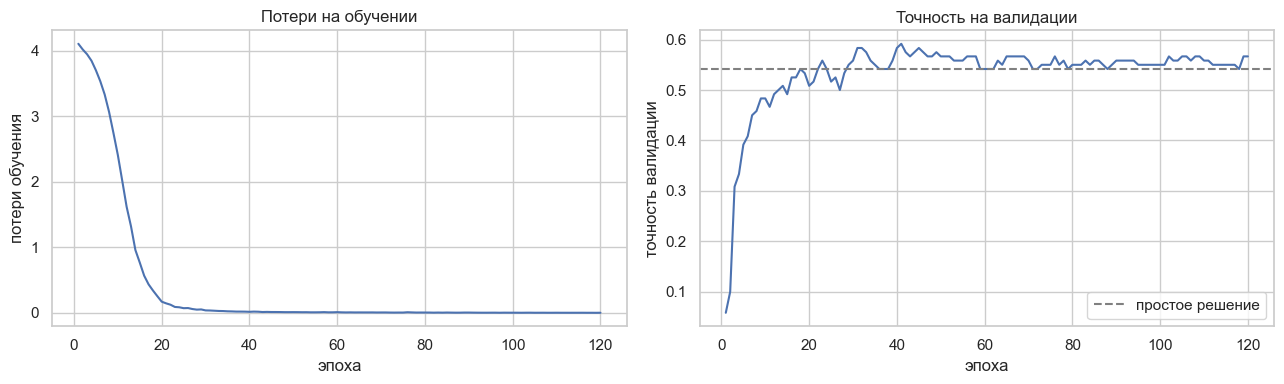

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=history, x="эпоха", y="потери обучения", ax=axes[0])
axes[0].set_title("Потери на обучении")
sns.lineplot(data=history, x="эпоха", y="точность валидации", ax=axes[1])
axes[1].axhline(
    accuracy_score(y_validation, centroid_validation_predictions),
    color="gray", linestyle="--", label="простое решение"
)
axes[1].set_title("Точность на валидации")
axes[1].legend()
plt.tight_layout()

Падение потерь на обучении само по себе не доказывает улучшение модели. Если валидационная кривая перестала расти или ухудшилась, сеть начинает запоминать две обучающие фразы каждого интента. В такой ситуации лучше оставить более раннюю эпоху, уменьшить сеть или собрать больше разметки.

## 5. Валидация и ошибки

Посмотрим на точность и Macro F1. Macro F1 считает F1 каждого интента отдельно и усредняет их, поэтому класс с большим числом примеров не может скрыть ошибки в редких классах. В нашей ровной выборке обе метрики полезны.

In [7]:
resnet_validation_predictions = predict(model, validation_loader)
print(f"Точность ResNet: {accuracy_score(y_validation, resnet_validation_predictions):.3f}")
print(f"Macro F1 ResNet: {f1_score(y_validation, resnet_validation_predictions, average='macro'):.3f}")

report = pd.DataFrame(
    classification_report(
        y_validation, resnet_validation_predictions,
        target_names=classes, output_dict=True, zero_division=0
    )
).T
display(report.loc[classes, ["precision", "recall", "f1-score"]].sort_values("f1-score").head(12))

Точность ResNet: 0.592
Macro F1 ResNet: 0.536


,precision,recall,f1-score
weather_query,0.0,0.0,0.0
play_audiobook,0.0,0.0,0.0
news_query,0.0,0.0,0.0
qa_factoid,0.0,0.0,0.0
lists_query,0.0,0.0,0.0
iot_hue_lightup,0.0,0.0,0.0
social_post,0.0,0.0,0.0
play_music,0.0,0.0,0.0
takeaway_query,0.0,0.0,0.0
email_query,0.0,0.0,0.0


In [8]:
validation_analysis = validation[["text", "intent"]].copy()
validation_analysis["предсказанный интент"] = [id_to_intent[index] for index in resnet_validation_predictions]
errors = validation_analysis.loc[
    validation_analysis["intent"] != validation_analysis["предсказанный интент"]
].copy()
errors = errors.rename(columns={"intent": "истинный интент"})
print(f"Ошибок: {len(errors)} из {len(validation_analysis)}")
display(errors.head(15))

Ошибок: 49 из 120


,text,истинный интент,предсказанный интент
0,пожалуйста ставь только грустную музыку на плеере,play_music,music_query
1,соревнования по бегу в приморском районе,recommendation_events,recommendation_locations
2,я хочу послушать песни группы сплин пожалуйста...,play_music,music_query
5,что мне нужно сделать завтра,calendar_query,calendar_set
8,я не мог расслышать повтори это громче,audio_volume_up,music_dislikeness
11,instagram,social_query,social_post
12,покажи мне номер службы поддержки клиентов mcd...,social_post,email_query
18,прибавь громкость пожалуйста,audio_volume_other,audio_volume_up
20,убери будильник на семь тридцать утра в понеде...,alarm_remove,alarm_set
23,пожалуйста будь тихим на следующие два часа,audio_volume_mute,audio_volume_down


При чтении ошибок проверяйте не только совпадение названий. Близкие интенты могут быть неоднозначны даже для человека, а два примера на класс не покрывают все формулировки. Полезные вопросы: какие слова или ситуации путаются, есть ли ошибочные метки, и поможет ли дополнительная разметка.

## 6. Предсказания для проверочной выборки

Файл должен содержать только `query_id` и предсказанный `intent`. У проверочной выборки нет меток в коде модели: мы создаём файл, а отдельный локальный валидатор читает открытый эталон.

In [9]:
evaluation_loader = make_loader(evaluation_vectors)
evaluation_predictions = predict(model, evaluation_loader)

intent_predictions = pd.DataFrame({
    "query_id": evaluation["query_id"],
    "intent": [id_to_intent[index] for index in evaluation_predictions],
})
intent_predictions.to_csv("intent_predictions.csv", index=False)
intent_predictions.head(), intent_predictions.shape

(  query_id           intent
 0     0001        play_game
 1     0002  iot_hue_lighton
 2     0003   calendar_query
 3     0004      iot_wemo_on
 4     0005     iot_cleaning,
 (120, 2))

In [ ]:
# Запустите в консоли команду
# python validate_intent_classification.py --predictions intent_predictions.csv

## Ваша ЗАДАЧА

1. Измените ширину сети, число блоков ResNet и долю отключаемых нейронов. Выберите один вариант только по валидации и объясните результат
2. Добавьте раннюю остановку: прекращайте обучение, если валидационная точность не улучшалась 15 эпох
3. Сравните ResNet с простым решением по центроидам. Почему при столь малой разметке более сложная сеть может проиграть?
4. Для следующего эксперимента увеличьте обучающую часть: перенесите часть данных только из `validation_labeled.csv` в обучение, но не используйте `evaluation_labels.csv` и честно отметьте, что валидация изменилась.